<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 2px solid #7b1fa2; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); text-align: center; direction: rtl; font-family: 'Vazir', Tahoma, sans-serif;">
<div style="color: #4a148c; font-size: 2em; font-weight: bold; margin-bottom: 8px;">کتاب درک شهودی یادگیری ماشین</div>
<hr style="border: none; border-top: 2px solid #7b1fa2; width: 50%; margin: 12px auto;">
<h2 style="color: #4a148c; margin: 0; font-size: 1.5em; border-bottom: none;">فصل هفدهم: تشخیص ناهنجاری</h2>
</div>

<div dir="rtl" align="right">

# فصل ۱۷ | تشخیص ناهنجاری در شمارش روزانهٔ شیکاگو
این دفترچه، **غربالگری توصیفی** روی رکوردهای ثبت‌شدهٔ سال ۲۰۲۱ است؛ پیش‌بینی آینده یا تأیید وقوع رویداد غیرعادی نیست. Z-Score فقط شمار سرقت را می‌سنجد. Isolation Forest شمار سرقت و ضرب‌وجرح را هم‌زمان بررسی می‌کند. خروجی هر دو برای بازبینی داده و زمینهٔ زمانی است، نه قضاوت دربارهٔ افراد یا محله‌ها.

فایل کوچک همراه دفترچه، ۲۰۱٬۲۲۱ ردیف سال ۲۰۲۱ از `Crime_data from 2001 to present.csv` کتاب است؛ فقط سه ستون ID، Date و Primary Type در آن نگه داشته شده‌اند. هر سطر یک رکورد است و تکرار زمان و نوع جرم به‌معنای تکرار رکورد نیست.


</div>

<div dir="rtl" align="right">

## گام ۱ بارگذاری، تاریخ و پوشش روزها
تاریخ را با قالب واقعی فایل به datetime تبدیل می‌کنیم. پیش از تحلیل، یکتایی شناسه و وجود داده در همهٔ ۳۶۵ روز را می‌سنجیم؛ روز فاقد رکورد را به‌صورت خودکار صفر نمی‌گذاریم.


</div>

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

data_dir = Path("../data") if Path("../data").is_dir() else Path("data")
file = data_dir / "Chicago_2021_Incidents.csv"
# قالب تاریخ فایل دقیقاً ماه/روز/سال ساعت:دقیقه است.
records = pd.read_csv(file, usecols=["ID", "Date", "Primary Type"])
records["Date"] = pd.to_datetime(records["Date"], format="%m/%d/%Y %H:%M")
assert records["ID"].is_unique
assert records["Date"].dt.year.eq(2021).all()
records["Day"] = records["Date"].dt.normalize()
calendar = pd.date_range("2021-01-01", "2021-12-31", freq="D")
# هر روز سال باید در داده وجود داشته باشد؛ در غیر این صورت تحلیل را متوقف کن.
daily = pd.crosstab(records["Day"], records["Primary Type"])
assert daily.index.equals(calendar), "Missing days in 2021"
daily = daily[["THEFT", "BATTERY"]].rename(
    columns={"THEFT": "Theft", "BATTERY": "Battery"})
print("Rows:", len(records), "Days:", len(daily))
print(daily.describe().round(1).to_string())


Rows: 201221 Days: 365
Primary Type  Theft  Battery
count         365.0    365.0
mean          107.5    110.3
std            25.2     24.1
min            37.0     62.0
25%            89.0     94.0
50%           108.0    108.0
75%           125.0    124.0
max           218.0    189.0


<div dir="rtl" align="right">

## گام ۲ Z-Score برای شمار روزانهٔ سرقت
میانگین و انحراف معیار از همین ۳۶۵ روز محاسبه می‌شوند. آستانهٔ `|Z| >= 3` یک انتخاب آموزشی برای غربالگری است؛ مثبت یا منفی بودن فقط جهت انحراف را نشان می‌دهد.


</div>

In [2]:
mean = daily["Theft"].mean()
# ddof=0 برای انحراف معیار توصیفی همین سال؛ در دو اجرای مقایسه ثابت می‌ماند.
std = daily["Theft"].std(ddof=0)
assert std > 0
daily["Z_Theft"] = (daily["Theft"] - mean) / std
daily["Z_Flag"] = daily["Z_Theft"].abs() >= 3
print("Z-Score alerts:", int(daily["Z_Flag"].sum()))
print(daily.loc[daily["Z_Flag"], ["Theft", "Z_Theft"]]
      .round(2).to_string())


Z-Score alerts: 3
Primary Type  Theft  Z_Theft
Day                         
2021-07-29      191     3.31
2021-07-30      197     3.55
2021-07-31      218     4.38


<div dir="rtl" align="right">

## گام ۳ Isolation Forest با دو شمارش روزانه
این مدل بدون برچسب واقعی آموزش می‌بیند. `contamination=0.03` مرزِ علامت‌گذاری حدود سه درصد روزها را تعیین می‌کند؛ سهم واقعی ناهنجاری‌های شهر را اندازه نمی‌گیرد. در `decision_function` امتیاز منفی‌تر یعنی نمونه با این تنظیمات غیرمعمول‌تر است. بذر ثابت خروجی را تکرارپذیر می‌کند.


</div>

In [3]:
features = daily[["Theft", "Battery"]]
# نرخ ۳ درصد آستانهٔ آموزشی است، نه برآورد فراوانی واقعی ناهنجاری‌ها.
forest = IsolationForest(n_estimators=200, contamination=0.03,
                         random_state=42)
daily["IF_Flag"] = forest.fit_predict(features) == -1
daily["IF_Score"] = forest.decision_function(features)
print("Isolation Forest alerts:", int(daily["IF_Flag"].sum()))
print("Flagged by both:", int((daily["Z_Flag"] & daily["IF_Flag"]).sum()))
print(daily.loc[daily["IF_Flag"],
                ["Theft", "Battery", "Z_Theft", "IF_Score"]]
      .sort_values("IF_Score").round(2).to_string())


Isolation Forest alerts: 11
Flagged by both: 3
Primary Type  Theft  Battery  Z_Theft  IF_Score
Day                                            
2021-07-31      218      171     4.38     -0.17
2021-07-30      197      100     3.55     -0.09
2021-07-29      191      126     3.31     -0.08
2021-06-20      101      189    -0.26     -0.06
2021-02-15       37       80    -2.80     -0.05
2021-08-01      170      149     2.48     -0.04
2021-02-16       44       75    -2.52     -0.04
2021-07-04      105      188    -0.10     -0.03
2021-06-06      110      184     0.10     -0.03
2021-07-05      105      187    -0.10     -0.03
2021-05-23       97      174    -0.42     -0.00


<div dir="rtl" align="right">

## گام ۴ نمودار و تفسیر
نمودار بالایی روزهای علامت‌گذاری‌شده با Z-Score را روی سری شمارش سرقت نشان می‌دهد؛ نمودار پایین، ترکیب شمارش دو نوع جرم و روزهای علامت‌گذاری‌شده با Isolation Forest را نشان می‌دهد. یک روز می‌تواند با دو معیار علامت بخورد. چون این مثال فصل، روز هفته، فصل، تغییر حجم گزارش‌دهی و خطاهای ثبت را مدل نمی‌کند، تفسیر علت هر علامت نیازمند بررسی جداگانه است.


</div>

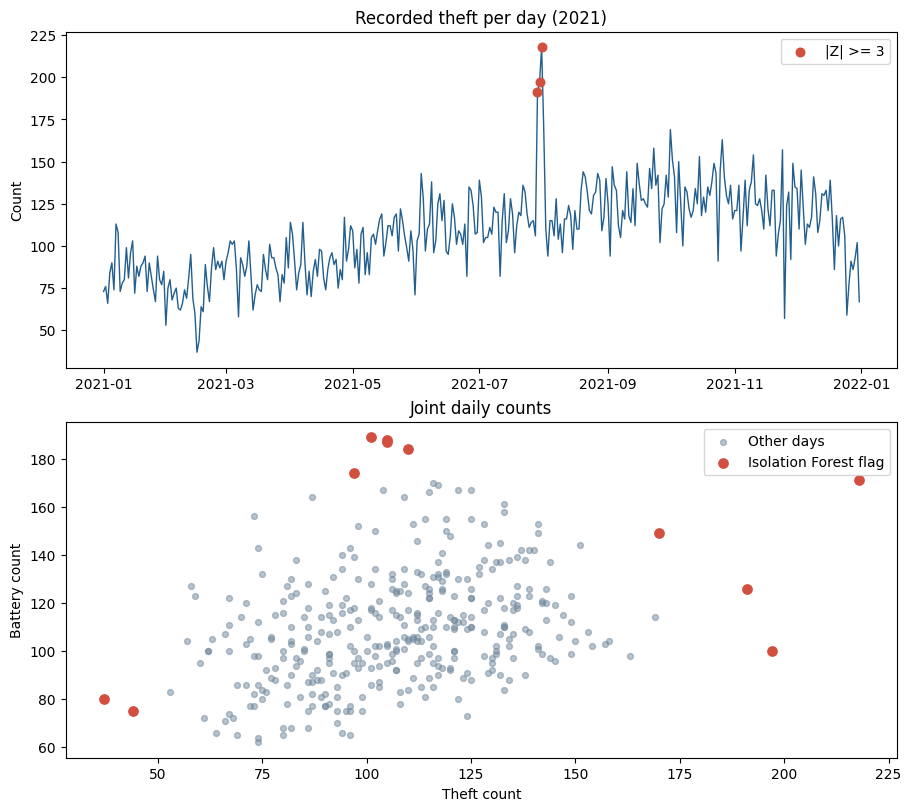

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8), constrained_layout=True)
axes[0].plot(daily.index, daily["Theft"], lw=1, color="#225f8f")
axes[0].scatter(daily.index[daily["Z_Flag"]],
                daily.loc[daily["Z_Flag"], "Theft"],
                color="#d14f3f", s=38, label="|Z| >= 3", zorder=3)
axes[0].set(title="Recorded theft per day (2021)", ylabel="Count")
axes[0].legend()
axes[1].scatter(daily["Theft"], daily["Battery"],
                s=18, alpha=.5, color="#71899c", label="Other days")
flagged = daily.loc[daily["IF_Flag"]]
axes[1].scatter(flagged["Theft"], flagged["Battery"],
                s=45, color="#d14f3f", label="Isolation Forest flag")
axes[1].set(xlabel="Theft count", ylabel="Battery count",
            title="Joint daily counts")
axes[1].legend()
plt.show()


<div dir="rtl" align="right">

### برداشت
در این فایل، Z-Score با آستانهٔ ۳ سه روز و Isolation Forest با نرخ تعیین‌شدهٔ ۰٫۰۳ یازده روز را علامت می‌زند؛ هر سه روز روش اول در خروجی روش دوم نیز هستند. علامتِ الگوریتم کشف جرم، خطای قطعی داده یا خطر منطقه‌ای را اثبات نمی‌کند. این مثال صرفاً روی رکوردهای موجود و کل سال ۲۰۲۱ برازش شده است؛ برای هشدار عملیاتی باید الگوی روز هفته/فصل، کیفیت ثبت، دادهٔ تاریخی مستقل و اعتبارسنجی جدا بررسی شوند.

منبع روش: مستندات رسمی scikit-learn برای `IsolationForest` و راهنمای Outlier Detection؛ تعریف Z-Score در راهنمای SciPy.


</div>